In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd

data = {
    'Project_Type':[
        'Substation','Transmission Line','UG Cable','Substation',
        'Transmission Line','UG Cable','Substation','Transmission Line',
        'UG Cable','Substation','Transmission Line','UG Cable',
        'Substation','Transmission Line','UG Cable','Substation',
        'Transmission Line','UG Cable','Substation','Transmission Line',
        'UG Cable','Substation','Transmission Line','UG Cable',
        'Substation','Transmission Line','UG Cable','Substation',
        'Transmission Line','UG Cable','Substation','Transmission Line'
    ],

    'Material_Cost':[
        100,150,200,180,220,170,130,210,
        160,190,240,180,120,230,175,195,
        260,185,145,215,205,165,255,175,
        140,225,195,185,245,170,155,235
    ],

    'Labour_Cost':[
        20,30,40,35,45,25,28,42,
        32,38,48,34,22,44,29,37,
        50,31,24,43,39,27,47,30,
        23,46,36,33,49,28,26,45
    ],

    'Vendor_Score':[
        8,6,7,4,5,9,7,6,
        8,5,4,9,8,5,7,6,
        4,8,9,5,6,7,4,8,
        9,5,6,7,4,8,9,5
    ],

    'Weather_Risk':[
        2,5,3,8,7,2,4,6,
        3,7,8,2,3,6,4,5,
        8,2,1,7,5,4,8,2,
        1,7,5,4,8,2,1,6
    ],

    'Manpower':[
        50,40,60,30,25,55,45,35,
        52,28,22,58,48,34,56,42,
        20,62,65,27,39,51,24,59,
        63,26,41,53,23,57,64,29
    ],

    'Delay_Days':[
        10,20,8,35,40,5,15,28,
        12,32,42,4,11,25,9,18,
        45,3,2,34,22,14,39,6,
        1,31,19,13,41,7,2,27
    ]
}

df = pd.DataFrame(data)

df.to_csv("powergrid_projects.csv", index=False)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (32, 7)
        Project_Type  Material_Cost  Labour_Cost  Vendor_Score  Weather_Risk  \
0         Substation            100           20             8             2   
1  Transmission Line            150           30             6             5   
2           UG Cable            200           40             7             3   
3         Substation            180           35             4             8   
4  Transmission Line            220           45             5             7   

   Manpower  Delay_Days  
0        50          10  
1        40          20  
2        60           8  
3        30          35  
4        25          40  


In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Project_Type'] = encoder.fit_transform(df['Project_Type'])

print(df.head())

   Project_Type  Material_Cost  Labour_Cost  Vendor_Score  Weather_Risk  \
0             0            100           20             8             2   
1             1            150           30             6             5   
2             2            200           40             7             3   
3             0            180           35             4             8   
4             1            220           45             5             7   

   Manpower  Delay_Days  
0        50          10  
1        40          20  
2        60           8  
3        30          35  
4        25          40  


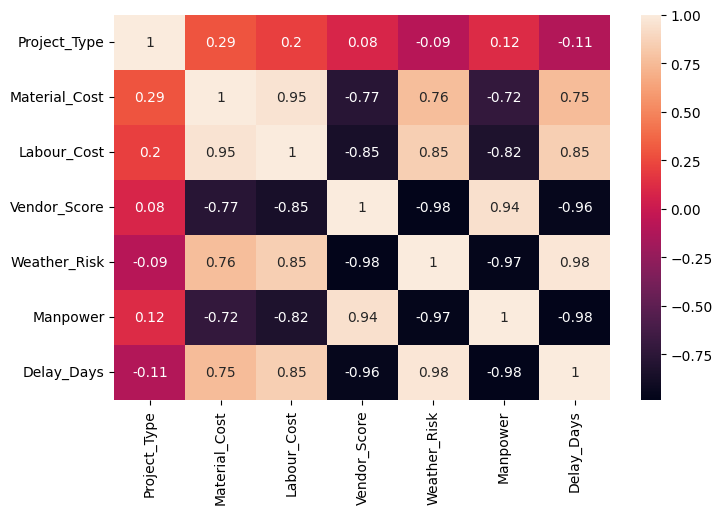

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(),annot=True)

plt.show()

In [5]:
X = df[['Project_Type',
        'Material_Cost',
        'Labour_Cost',
        'Vendor_Score',
        'Weather_Risk',
        'Manpower']]

y = df['Delay_Days']

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Data:",len(X_train))
print("Test Data:",len(X_test))

Train Data: 25
Test Data: 7


In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

print("AI Model Training Completed Successfully")

AI Model Training Completed Successfully


In [8]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions)

Predictions:
[ 6.58 18.9   4.2   6.19 10.52 31.21  4.63]


In [9]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)

print("Mean Absolute Error:",mae)

Mean Absolute Error: 1.8014285714285714


In [10]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.4 MB/s eta 0:00:00


In [11]:
import streamlit as st

st.title("POWERGRID Delay Predictor")

project_type = st.selectbox(
    "Project Type",
    ["Substation","Transmission Line","UG Cable"]
)

material_cost = st.number_input("Material Cost")
labour_cost = st.number_input("Labour Cost")
vendor_score = st.slider("Vendor Score",1,10)
weather_risk = st.slider("Weather Risk",1,10)
manpower = st.number_input("Manpower")

if st.button("Predict"):
    st.write("Prediction will appear here")

2026-06-17 07:22:34.132 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.327 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-17 07:22:34.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.330 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 07:22:34.335 Thread 'MainThread': mi

In [13]:
import ipywidgets as widgets
from IPython.display import display

project_type = widgets.Dropdown(
    options=[('Substation',0),
             ('Transmission Line',1),
             ('UG Cable',2)],
    description='Project:'
)

material_cost = widgets.IntText(
    value=150,
    description='Material:'
)

labour_cost = widgets.IntText(
    value=30,
    description='Labour:'
)

vendor_score = widgets.IntSlider(
    value=7,
    min=1,
    max=10,
    description='Vendor:'
)

weather_risk = widgets.IntSlider(
    value=4,
    min=1,
    max=10,
    description='Weather:'
)

manpower = widgets.IntText(
    value=50,
    description='Manpower:'
)

button = widgets.Button(description="Predict")

output = widgets.Output()

def predict(b):
    with output:
        output.clear_output()

        data = [[
            project_type.value,
            material_cost.value,
            labour_cost.value,
            vendor_score.value,
            weather_risk.value,
            manpower.value
        ]]

        prediction = model.predict(data)

        print(f"Predicted Delay Days: {prediction[0]:.2f}")

button.on_click(predict)

display(
    project_type,
    material_cost,
    labour_cost,
    vendor_score,
    weather_risk,
    manpower,
    button,
    output
)

Dropdown(description='Project:', options=(('Substation', 0), ('Transmission Line', 1), ('UG Cable', 2)), value…

IntText(value=150, description='Material:')

IntText(value=30, description='Labour:')

IntSlider(value=7, description='Vendor:', max=10, min=1)

IntSlider(value=4, description='Weather:', max=10, min=1)

IntText(value=50, description='Manpower:')

Button(description='Predict', style=ButtonStyle())

Output()